##**Step 1: Download the dataset from Kaggle**

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("junaid512/credit-scoring-dataset-creditworthiness-prediction")

print("Path to dataset files:", path)

100%|██████████| 228k/228k [00:00<00:00, 414kB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/junaid512/credit-scoring-dataset-creditworthiness-prediction/versions/1


## **Step 2: Import Required Libraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## **Step 3: Load Dataset**

In [4]:
import os

os.listdir(path)


['data.csv']

In [6]:
df = pd.read_csv(os.path.join(path, "data.csv"))


## **Step 4: View Dataset Information**

In [7]:
df.head()


,Age,Gender,Education,Income,Debt,Credit_Score,Loan_Amount,Loan_Term,Num_Credit_Cards,Payment_History,Employment_Status,Residence_Type,Marital_Status,Creditworthiness
0,56,Female,Master,149406,34089,581,49200,60,4,Bad,Unemployed,Rented,Single,1
1,69,Female,High School,78896,8626,648,20147,24,7,Good,Employed,Mortgaged,Married,1
2,46,Female,Master,119339,46281,329,41307,12,8,Bad,Unemployed,Owned,Single,1
3,32,Male,High School,131067,29403,816,19019,60,8,Bad,Employed,Owned,Single,1
4,60,Male,PhD,38001,30032,673,16317,36,4,Average,Employed,Rented,Married,0


In [9]:
df.shape

(12000, 14)

In [10]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Age                12000 non-null  int64 
 1   Gender             12000 non-null  object
 2   Education          12000 non-null  object
 3   Income             12000 non-null  int64 
 4   Debt               12000 non-null  int64 
 5   Credit_Score       12000 non-null  int64 
 6   Loan_Amount        12000 non-null  int64 
 7   Loan_Term          12000 non-null  int64 
 8   Num_Credit_Cards   12000 non-null  int64 
 9   Payment_History    12000 non-null  object
 10  Employment_Status  12000 non-null  object
 11  Residence_Type     12000 non-null  object
 12  Marital_Status     12000 non-null  object
 13  Creditworthiness   12000 non-null  int64 
dtypes: int64(8), object(6)
memory usage: 1.3+ MB


In [11]:
df.describe()


,Age,Income,Debt,Credit_Score,Loan_Amount,Loan_Term,Num_Credit_Cards,Creditworthiness
count,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,43.489250,85222.009417,25354.673250,573.967583,25113.951250,35.943000,4.985833,0.702583
std,14.908982,37640.043409,14087.390846,157.816052,14247.092051,16.965162,2.593458,0.457140
min,18.000000,20026.000000,1001.000000,300.000000,501.000000,12.000000,1.000000,0.000000
25%,31.000000,52400.750000,13161.000000,437.000000,12725.000000,24.000000,3.000000,0.000000
50%,43.000000,85756.000000,25382.500000,574.000000,25220.500000,36.000000,5.000000,1.000000
75%,56.000000,117754.750000,37497.500000,709.000000,37348.000000,48.000000,7.000000,1.000000
max,69.000000,149984.000000,49995.000000,849.000000,49996.000000,60.000000,9.000000,1.000000


## **Step 5: Check Missing Values**

In [12]:
df.isnull().sum()


,0
Age,0
Gender,0
Education,0
Income,0
Debt,0
Credit_Score,0
Loan_Amount,0
Loan_Term,0
Num_Credit_Cards,0
Payment_History,0


## **Step 6: Check if data is balanced or imbalanced**

In [23]:
y.value_counts()


,count
Creditworthiness,
1,8431
0,3569


## **Step 7: Label Encoding**

In [24]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = df.select_dtypes(include=["object"]).columns

le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])


## Step 8: **Split features and Target**

In [29]:
X = df.drop("Creditworthiness", axis=1)
y = df["Creditworthiness"]


## **Step 9: Balancing The Dataset (for avoiding bias)**

In [30]:
!pip install imbalanced-learn
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)


In [31]:
y_resampled.value_counts()


,count
Creditworthiness,
1,8431
0,8431


## **Step 10: Split the data into Train,Test**

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled,
    y_resampled,
    test_size=0.2,
    random_state=42
)


## **Step 11: Train Model ( Random Forest )**

In [33]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)


RandomForestClassifier(n_estimators=200, random_state=42)

## **Step 12: Predictions**

In [34]:
y_pred = model.predict(X_test)


##**Step 13: Evaluation**

In [35]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.7257634153572488
              precision    recall  f1-score   support

           0       0.76      0.65      0.70      1652
           1       0.70      0.80      0.75      1721

    accuracy                           0.73      3373
   macro avg       0.73      0.72      0.72      3373
weighted avg       0.73      0.73      0.72      3373



## **Step 14: Confusion Matrix**

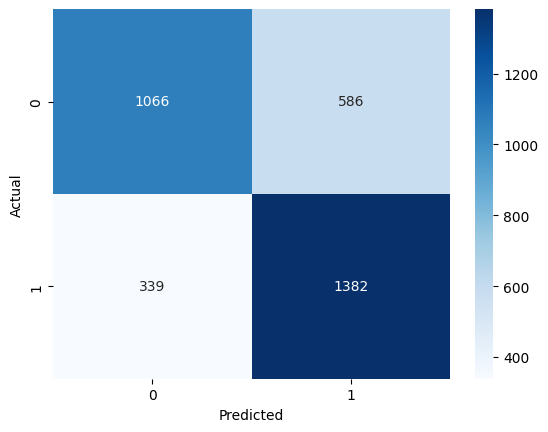

In [36]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
